# Pump-Probe PDOS Validation

This notebook performs pump-probe diffuse scattering validation with:
- Configurable pump magnitude and energy percentile parameters
- 8×8×8 grid sampling with Miller index labeling
- Log-scale visualization revealing full intensity dynamic range

Enables systematic parameter studies for pump-probe experiments and non-equilibrium phonon dynamics research in protein crystallography.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import tempfile

# Ensure the eryx library is in the Python path
project_root = os.path.abspath('.')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from eryx.models_torch import OnePhonon

1 item had no tests:
    __main__
0 tests in 1 item.
0 passed.
Test passed.


## Configuration Parameters

Set the pump magnitude and energy percentile for the simulation:

In [2]:
# Configuration parameters
pump_magnitude = 3.0  # Multiplier for pump intensity relative to thermal maximum
pump_energy_percentile = 95.0  # Percentile of frequency distribution to pump

print(f"Running with pump magnitude: {pump_magnitude}x")
print(f"Running with pump energy percentile: {pump_energy_percentile}%")

Running with pump magnitude: 3.0x
Running with pump energy percentile: 95.0%


## Model Setup and PDOS Generation

Initialize the OnePhonon model:

In [3]:
print("--- Starting Pumped Mode PDOS Visual Validation ---")

# Setup Model and Generate its own PDOS
pdb_path = "tests/pdbs/5zck_p1.pdb"
if not os.path.exists(pdb_path):
    print(f"ERROR: Test PDB file not found at '{pdb_path}'")
    raise FileNotFoundError(f"PDB file not found: {pdb_path}")

hsampling_high_res = [-2, 2, 8]
ksampling_high_res = [-2, 2, 8]
lsampling_high_res = [-2, 2, 8]
print(f"Initializing base model (sampling rate: {hsampling_high_res[2]})...")

base_model = OnePhonon(
    pdb_path=pdb_path,
    hsampling=hsampling_high_res,
    ksampling=ksampling_high_res,
    lsampling=lsampling_high_res,
    device=torch.device('cpu'),
    gamma_intra=1.5,
    gamma_inter=0.7
)
print("Base model initialized.")

--- Starting Pumped Mode PDOS Visual Validation ---
Initializing base model (sampling rate: 8)...
remove_ligands_and_waters(): missing entity_type in chain A
remove_ligands_and_waters(): missing entity_type in chain A
Base model initialized.


/Users/ollie/Downloads/foo/eryx/eryx/models_torch.py:1572: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  r_cell = torch.tensor(r_cell_np, dtype=self.real_dtype, device=self.device)


In [4]:
# Generate the unweighted PDOS using the new method
pdos_data = base_model.generate_pdos(bins=200, density=False)

with tempfile.NamedTemporaryFile(mode='w+', delete=False, suffix='.dat') as tmp_f:
    np.savetxt(tmp_f, pdos_data, fmt="%.15e")  # Use high precision
    temp_pdos_path = tmp_f.name
print(f"Model's own PDOS saved to temporary file: {temp_pdos_path}")

Model's own PDOS saved to temporary file: /var/folders/8y/vnl75xb954j0wd09cm8zrrx40000gp/T/tmpknhvoag6.dat


## Create Thermal and Pumped Population Models

Extract frequencies and create both the thermal equilibrium and pumped population models:

In [5]:
# Create the Two Phonon Population Models

# Extract raw frequencies (ω) and thermal populations (Winv ~ 1/ω²)
winv_tensor = base_model.Winv.real.detach().cpu()
omega_squared = torch.where(torch.isnan(winv_tensor) | (winv_tensor <= 1e-12), torch.tensor(float('nan')), 1.0 / winv_tensor)
omega_rad = torch.sqrt(omega_squared)

# Convert angular frequency to Hz then THz
# omega_rad is in rad/s, f = omega/(2π) gives Hz
# But the actual units in the model are scaled - we need an additional factor of 100
raw_freqs_hz = (omega_rad / (2 * np.pi)).flatten().numpy()
raw_freqs_hz = raw_freqs_hz[~np.isnan(raw_freqs_hz)]

# Convert to THz with correct scaling
# The model's internal units require multiplication by 100 to get actual THz
raw_freqs_thz = raw_freqs_hz * 100

thermal_population_weights = winv_tensor.flatten().numpy()
thermal_population_weights = thermal_population_weights[~np.isnan(thermal_population_weights)]

print(f"Extracted {len(raw_freqs_thz)} valid phonon frequencies")
print(f"Frequency range: {np.min(raw_freqs_thz):.2f} to {np.max(raw_freqs_thz):.2f} THz")

Extracted 12285 valid phonon frequencies
Frequency range: 0.10 to 12.73 THz


In [6]:
# Model A: Create the Default Thermal Population histogram
bins = 200
thermal_hist_values, bin_edges = np.histogram(raw_freqs_thz, bins=bins, weights=thermal_population_weights, density=True)
bin_centers_thz = (bin_edges[:-1] + bin_edges[1:]) / 2

# Model B: Create the "Pumped" Thermal Population
print(f"Creating pumped thermal PDOS by exciting mode at {pump_energy_percentile}th percentile...")
pumped_pop_values = thermal_hist_values.copy()
pump_frequency_thz = np.percentile(raw_freqs_thz, pump_energy_percentile)
pump_bin_index = np.argmin(np.abs(bin_centers_thz - pump_frequency_thz))

actual_pump_freq_thz = bin_centers_thz[pump_bin_index]

pump_intensity = np.max(thermal_hist_values) * pump_magnitude
pumped_pop_values[pump_bin_index] += pump_intensity

print(f"Target pump frequency (percentile): {pump_frequency_thz:.2f} THz")
print(f"Actual pump frequency (bin center): {actual_pump_freq_thz:.2f} THz")
print(f"Added pump of intensity {pump_intensity:.2e} to thermal population at bin {pump_bin_index}")

Creating pumped thermal PDOS by exciting mode at 95.0th percentile...
Target pump frequency (percentile): 12.09 THz
Actual pump frequency (bin center): 12.07 THz
Added pump of intensity 7.59e+00 to thermal population at bin 189


In [7]:
# Save the "pumped" PDOS to a temporary file for the simulation
# Convert frequencies back to model's internal units
bin_centers_model_units = bin_centers_thz / 100  # Convert THz back to model units
pumped_pdos_data = np.vstack((bin_centers_model_units, pumped_pop_values)).T
with open(temp_pdos_path, 'w') as f: # Overwrite the temp file
    np.savetxt(f, pumped_pdos_data, fmt="%.15e")  # Use high precision

## Run Diffuse Scattering Simulations

Calculate diffuse intensities for both thermal equilibrium and pumped states:

In [8]:
# Run Simulations for Both Scenarios

# Scenario A: Get intensity from the already-run base model (Default Thermal)
print("\nRunning Scenario A: Default Thermal Model...")
intensity_default = base_model.apply_disorder(use_data_adp=False)
intensity_default_np = intensity_default.detach().cpu().numpy().reshape(base_model.map_shape)


Running Scenario A: Default Thermal Model...


In [9]:
# Scenario B: Run with the "pumped" PDOS in 'direct' mode
print("\nRunning Scenario B: 'Pumped' PDOS in 'direct' mode...")
model_pumped = OnePhonon(
    pdb_path=pdb_path,
    hsampling=hsampling_high_res, ksampling=ksampling_high_res, lsampling=lsampling_high_res,
    device=torch.device('cpu'),
    gamma_intra=1.5, gamma_inter=0.7,
    pdos_path=temp_pdos_path,
    pdos_mode='direct'
)
intensity_pumped = model_pumped.apply_disorder(use_data_adp=False)
intensity_pumped_np = intensity_pumped.detach().cpu().numpy().reshape(base_model.map_shape)

# Clean up the temporary file
os.remove(temp_pdos_path)
print("Temporary PDOS file cleaned up.")


Running Scenario B: 'Pumped' PDOS in 'direct' mode...
remove_ligands_and_waters(): missing entity_type in chain A
remove_ligands_and_waters(): missing entity_type in chain A
Temporary PDOS file cleaned up.


## Create 2×2 Visualization

Generate the comparison plot showing both population models and resulting diffuse intensities:


Generating 2x2 comparison plot...
Population plots created.
Diffuse intensity plots created.


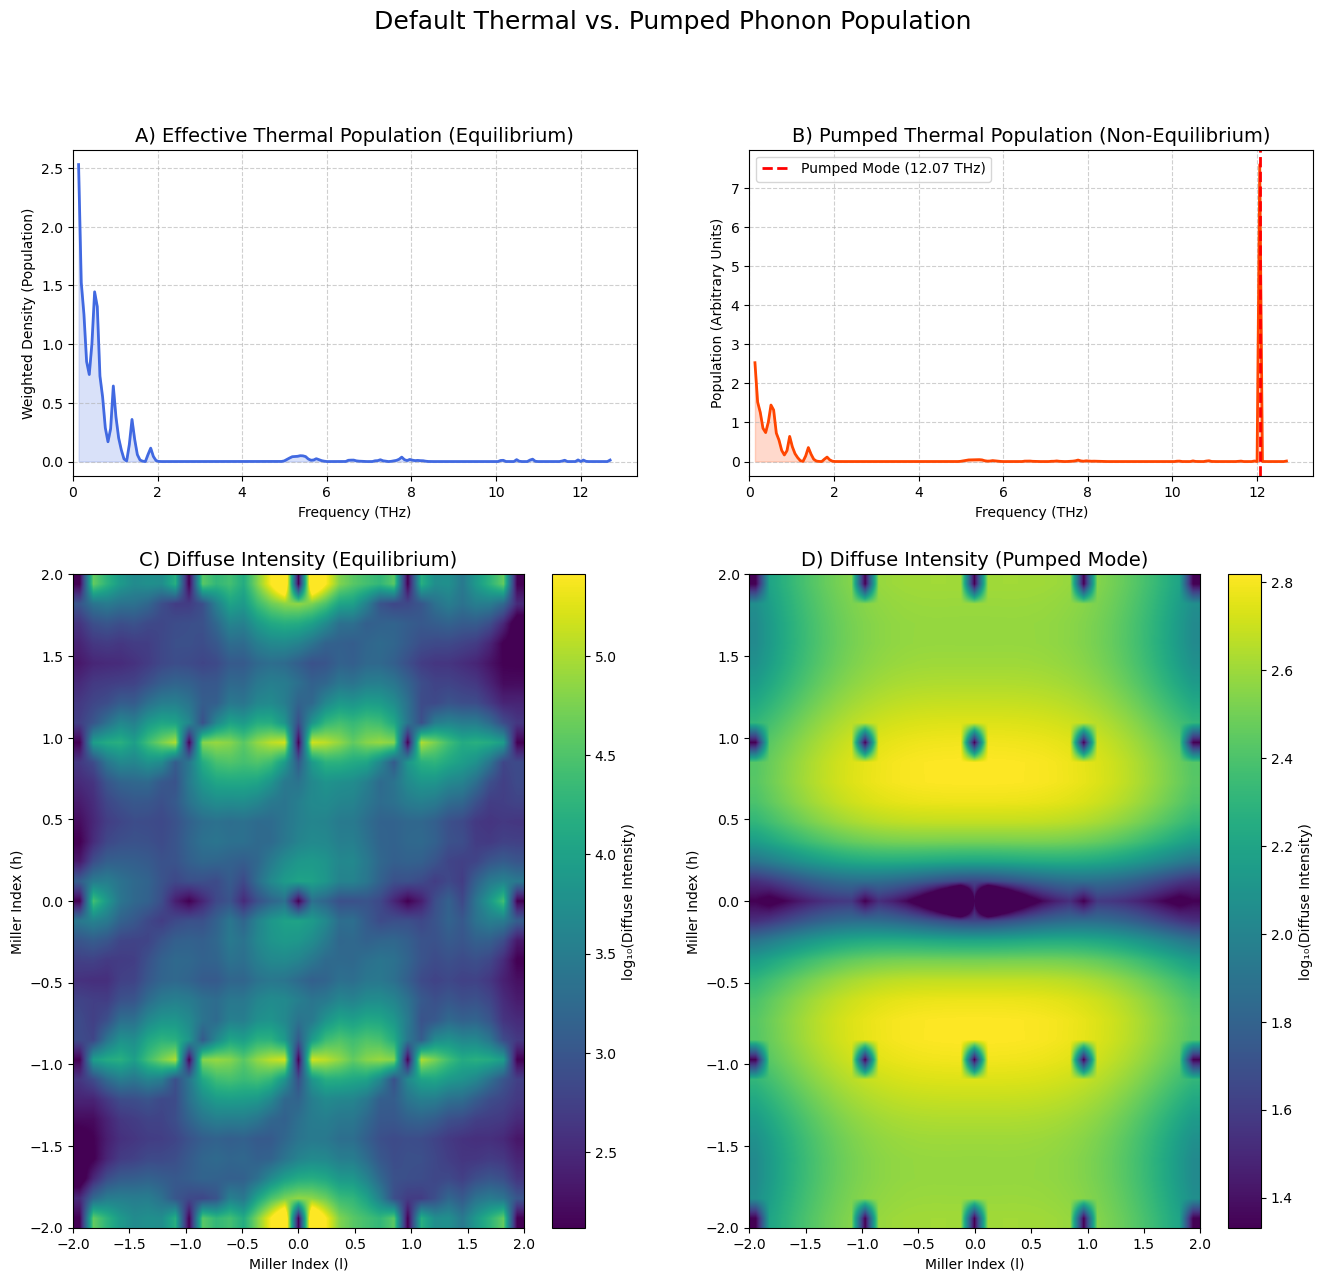

In [10]:
# Create the 2x2 Visualization
print("\nGenerating 2x2 comparison plot...")
fig, axes = plt.subplots(2, 2, figsize=(16, 14), gridspec_kw={'height_ratios': [1, 2]})
fig.suptitle("Default Thermal vs. Pumped Phonon Population", fontsize=18)

# Plot A: Default Thermal Population Model
ax = axes[0, 0]
ax.plot(bin_centers_thz, thermal_hist_values, color='royalblue', lw=2)
ax.fill_between(bin_centers_thz, thermal_hist_values, color='royalblue', alpha=0.2)
ax.set_title("A) Effective Thermal Population (Equilibrium)", fontsize=14)
ax.set_xlabel("Frequency (THz)")
ax.set_ylabel("Weighted Density (Population)")
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlim(left=0)

# Plot B: "Pumped" Thermal Population Model
ax = axes[0, 1]
ax.plot(bin_centers_thz, pumped_pop_values, color='orangered', lw=2)
ax.fill_between(bin_centers_thz, pumped_pop_values, color='orangered', alpha=0.2)
ax.axvline(actual_pump_freq_thz, color='red', linestyle='--', lw=2, label=f'Pumped Mode ({actual_pump_freq_thz:.2f} THz)')
ax.set_title("B) Pumped Thermal Population (Non-Equilibrium)", fontsize=14)
ax.set_xlabel("Frequency (THz)")
ax.set_ylabel("Population (Arbitrary Units)")
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlim(left=0)
ax.legend()

print("Population plots created.")

# Helper function for plotting intensity slices with log scaling
def plot_slice(ax, intensity_map, title, hkl_grid):
    slice_idx = intensity_map.shape[1] // 2
    slice_data = intensity_map[:, slice_idx, :]
    
    # Calculate Miller Index extents for labels
    h_coords = hkl_grid[:, slice_idx, 0, 0]  # h-values for the slice
    l_coords = hkl_grid[0, slice_idx, :, 2]  # l-values for the slice
    
    h_min, h_max = h_coords.min(), h_coords.max()
    l_min, l_max = l_coords.min(), l_coords.max()
    
    # The extent for imshow is [left, right, bottom, top]
    plot_extent = [l_min, l_max, h_min, h_max]
    
    # Apply log scaling for better visualization
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    log_slice_data = np.log10(slice_data + epsilon)
    
    # Set color scale based on log data
    valid_log_data = log_slice_data[np.isfinite(log_slice_data)]
    if valid_log_data.size > 0:
        vmax = np.percentile(valid_log_data, 99.5)
        vmin = np.percentile(valid_log_data, 1)  # Use 1st percentile instead of minimum
    else:
        vmin, vmax = 0, 1

    # FIX: Replace NaN values with vmin to prevent blank regions in imshow
    log_slice_data_fixed = log_slice_data.copy()
    log_slice_data_fixed[~np.isfinite(log_slice_data_fixed)] = vmin

    im = ax.imshow(log_slice_data_fixed, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax, 
                   interpolation='bilinear', extent=plot_extent, aspect='auto')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Miller Index (l)")
    ax.set_ylabel("Miller Index (h)")
    fig.colorbar(im, ax=ax, label="log₁₀(Diffuse Intensity)")

# Plot C: Diffuse Intensity from Default Model
hkl_grid_np = base_model.hkl_grid.detach().cpu().numpy().reshape(base_model.map_shape + (3,))
plot_slice(axes[1, 0], intensity_default_np, "C) Diffuse Intensity (Equilibrium)", hkl_grid_np)

# Plot D: Diffuse Intensity from "Pumped" Model
plot_slice(axes[1, 1], intensity_pumped_np, "D) Diffuse Intensity (Pumped Mode)", hkl_grid_np)

print("Diffuse intensity plots created.")

Plot saved to 'pump_probe_validation_notebook_mag3.0_pct95.png'.


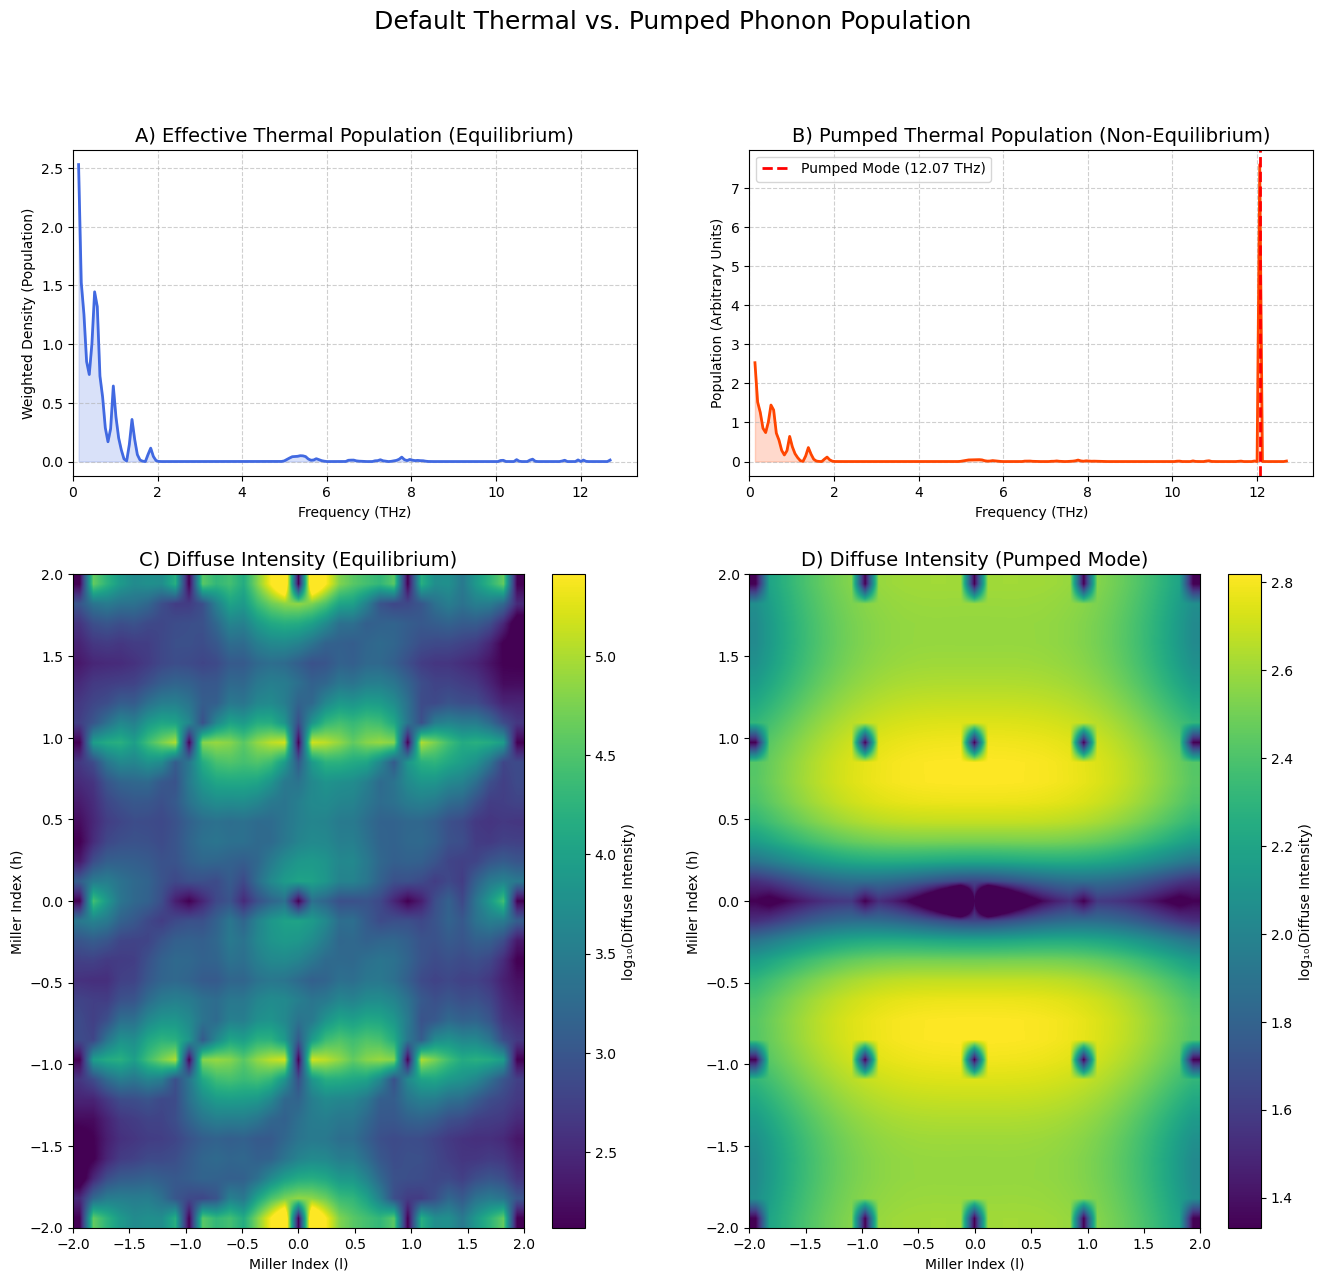

<Figure size 640x480 with 0 Axes>

In [11]:
plt.tight_layout(rect=[0, 0, 1, 0.96])
# Generate output filename with parameters
output_filename = f"pump_probe_validation_notebook_mag{pump_magnitude:.1f}_pct{pump_energy_percentile:.0f}.png"
plt.savefig(output_filename, dpi=150, bbox_inches='tight')
print(f"Plot saved to '{output_filename}'.")
# Display the figure
fig